# All required libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import ReduceLROnPlateau
import os


#  Data Loading



In [2]:
labels = ["PNEUMONIA", "NORMAL"]
img_resize = 150

def get_data(dir):
  data = []

  for label in labels:
    path = os.path.join(dir, label)

    class_num = labels.index(label)

    for img in os.listdir(path):
      try:
        if img.endswith("jpeg"):
          img_arr =  cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
          resized_arr = cv2.resize(img_arr,(img_resize, img_resize))
          data.append([resized_arr, class_num])
      except Exception as e:
       print(e)
  return np.array(data, dtype= "object")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Splitting

In [4]:
train = get_data("/content/drive/MyDrive/chest-xray/train")
test = get_data("/content/drive/MyDrive/chest-xray/test")
val = get_data("/content/drive/MyDrive/chest-xray/val")


# Data Visualization and Preprocessing

<Axes: xlabel='count'>

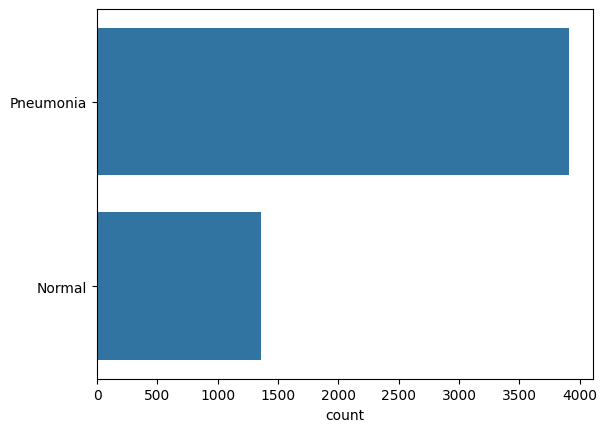

In [5]:
l = []
for i in train:
  if(i[1] == 0):
    l.append("Pneumonia")
  else:
    l.append("Normal")
sns.countplot(l)

Text(0.5, 1.0, 'NORMAL')

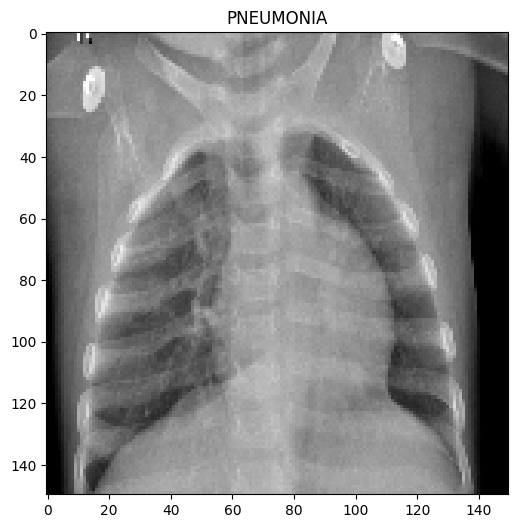

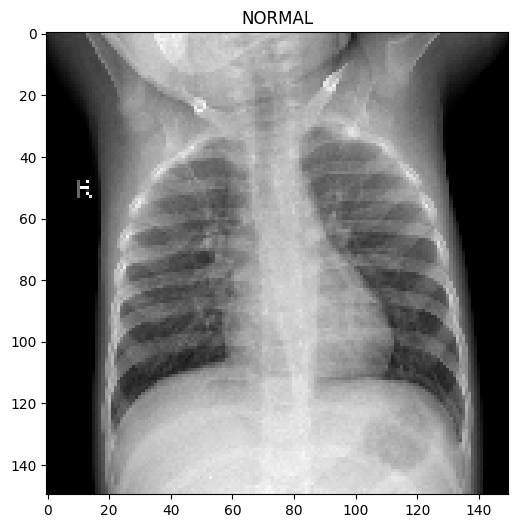

In [6]:
plt.figure(figsize=(6,6))
plt.imshow(train[0][0], cmap="gray")
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))
plt.imshow(train[-1][0], cmap="gray")
plt.title(labels[train[-11][1]])

In [7]:
x_train = []
y_train = []

x_test = []
y_test = []

x_val = []
y_val = []

for feat, label in train:
  x_train.append(feat)
  y_train.append(label)

for feat, label in test:
  x_test.append(feat)
  y_test.append(label)

for feat, label in val:
  x_val.append(feat)
  y_val.append(label)

# Normalize the data

In [8]:
x_train = np.array(x_train)/255
x_val = np.array(x_val)/255
x_test = np.array(x_test)/255

In [9]:
x_train

array([[[0.25882353, 0.29019608, 0.30196078, ..., 0.35686275,
         0.41568627, 0.44313725],
        [0.27058824, 0.30196078, 0.30588235, ..., 0.31764706,
         0.36078431, 0.39607843],
        [0.27843137, 0.28235294, 0.32941176, ..., 0.28627451,
         0.32156863, 0.33333333],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.00784314, 0.01568627, 0.01176471, ..., 0.00392157,
         0.        , 0.        ],
        [0.00784314, 0.01568627, 0.01176471, ..., 0.00392157,
         0.        , 0.        ],
        [0.00392157, 0.01568627, 0.01176471, ..., 0.00392157,
         0.        , 0.        ],
        ...,
        [0.05882353, 0.0745098 , 0.16078431, ..., 0.        ,
         0.        , 0.        ],
        [0.0

In [10]:
x_train = x_train.reshape(-1, img_resize, img_resize, 1)
y_train = np.array(y_train)

x_test= x_test.reshape(-1, img_resize, img_resize, 1)
y_test = np.array(y_test)

x_val = x_val.reshape(-1, img_resize, img_resize, 1)
y_val = np.array(y_val)

## Agument the data to balance

In [11]:
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=30,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.2,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)

# Training the model

In [12]:
model = Sequential()
model.add(Conv2D(32,(3,3), strides =1, padding='same', activation='relu', input_shape=(150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(64,(3,3), strides =1, padding='same', activation='relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(64,(3,3), strides =1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(128,(3,3), strides =1, padding='same', activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(256,(3,3), strides =1, padding='same', activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Flatten())
model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [13]:
learning_rate_reduction = ReduceLROnPlateau(monitor="val_accuracy", patience=2, verbose=1, factor=0.3, min_lr=0.000001)

# Fitting of data into the model

In [14]:
history = model.fit(x_train, y_train, batch_size = 32, epochs=18,
                    validation_data=datagen.flow(x_val, y_val),
                    callbacks=[learning_rate_reduction])

Epoch 1/18
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8357 - loss: 0.8789

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


165/165 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.8361 - loss: 0.8759 - val_accuracy: 0.5000 - val_loss: 23.4398 - learning_rate: 0.0010
Epoch 2/18
165/165 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.9576 - loss: 0.1370 - val_accuracy: 0.5000 - val_loss: 32.3139 - learning_rate: 0.0010
Epoch 3/18
163/165 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9733 - loss: 0.0880
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9733 - loss: 0.0880 - val_accuracy: 0.5000 - val_loss: 30.4010 - learning_rate: 0.0010
Epoch 4/18
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9880 - loss: 0.0402 - val_accuracy: 0.5000 - val_loss: 18.7862 - learning_rate: 3.0000e-04
Epoch 5/18
163/165 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9889 - loss: 0.0338
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9890 - loss: 0.033

# Evaluating Model Accuracy and loss

In [15]:
model.evaluate(x_test, y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9265 - loss: 0.8552


[3.1348788738250732, 0.7419871687889099]

In [16]:
print(f"Accuracy of the model : {model.evaluate(x_test, y_test)[1]*100}%")
print(f"Loss of the model : {model.evaluate(x_test, y_test)[0]}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9265 - loss: 0.8552
Accuracy of the model : 74.19871687889099%
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9265 - loss: 0.8552
Loss of the model : 3.1348788738250732


# Analyse Model performance

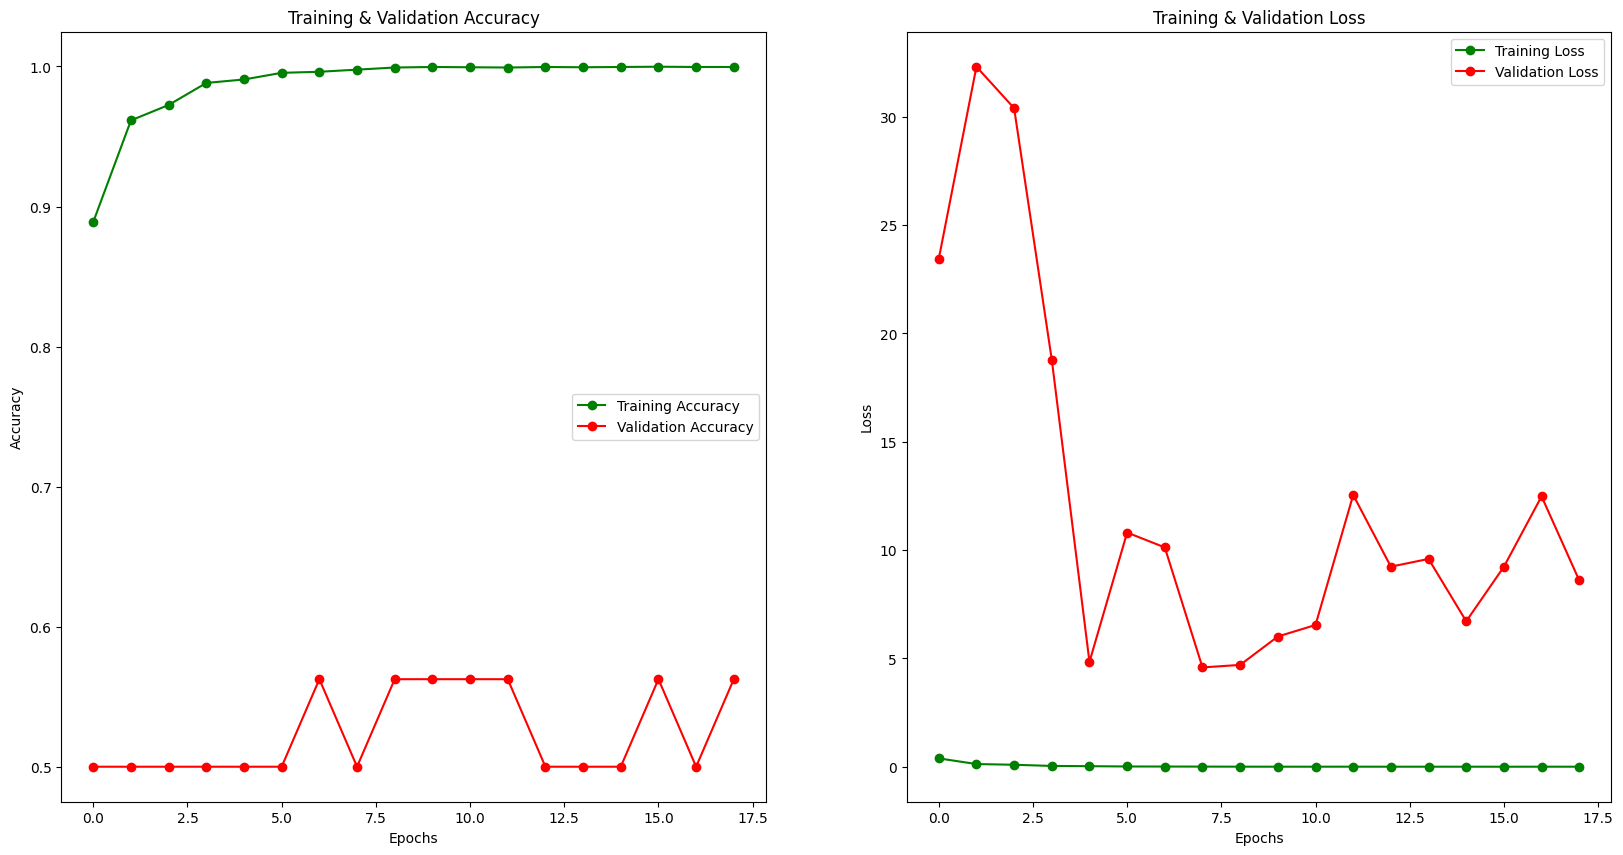

In [17]:
epochs = [i for i in range(18)]
fig, ax = plt.subplots(1,2)
train_acc = history.history["accuracy"]
train_loss = history.history["loss"]
val_acc = history.history["val_accuracy"]
val_loss = history.history["val_loss"]

fig.set_size_inches(20,10)
ax[0].plot(epochs, train_acc, 'go-', label="Training Accuracy")
ax[0].plot(epochs, val_acc, "ro-", label="Validation Accuracy")
ax[0].set_title("Training & Validation Accuracy")
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs, train_loss, 'g-o', label="Training Loss")
ax[1].plot(epochs, val_loss, "r-o", label="Validation Loss")
ax[1].set_title("Training & Validation Loss")
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
plt.show()

In [18]:
predictions = (model.predict(x_test) > 0.5).astype("int32")
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

# Model's Classification report

In [19]:
print(classification_report(y_test, predictions, target_names = ["Pneumonia (class 0)", "Normal (class 1)"]))

                     precision    recall  f1-score   support

Pneumonia (class 0)       0.71      1.00      0.83       390
   Normal (class 1)       1.00      0.31      0.48       234

           accuracy                           0.74       624
          macro avg       0.85      0.66      0.65       624
       weighted avg       0.82      0.74      0.70       624



# Confusion Matrix

In [20]:
cm = confusion_matrix(y_test, predictions)
cm

array([[390,   0],
       [161,  73]])

In [25]:
correct = np.nonzero(predictions == y_test)[0]
correct
incorrect = np.nonzero(predictions != y_test)[0]
# # incorrect

# Visualization of correctly predictions classes

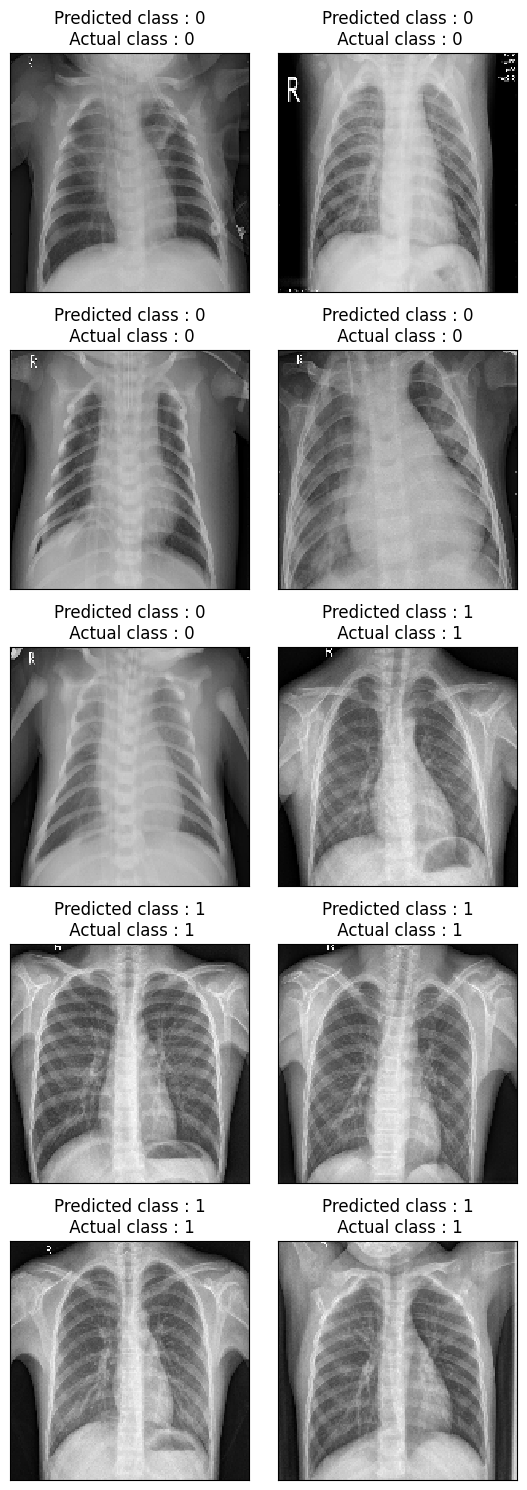

In [26]:
i = 0

plt.figure(figsize=(6,15))
for c in correct[385:395]:
  plt.subplot(5,2, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation="none")
  plt.title(f"Predicted class : {predictions[c]}\n Actual class : {y_test[c]}")
  plt.tight_layout()
  i +=1


# Visualization of incorrected predicted  classes

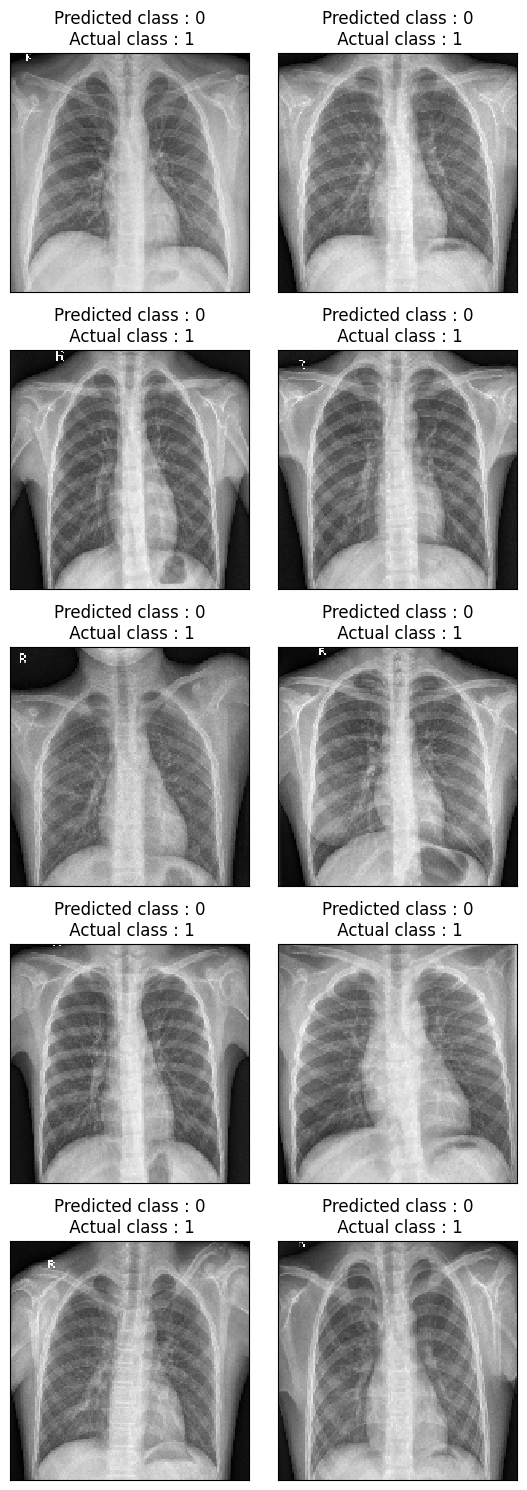

In [27]:
i = 0

plt.figure(figsize=(6,15))
for c in incorrect[:10]:
  plt.subplot(5,2, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation="none")
  plt.title(f"Predicted class : {predictions[c]}\n Actual class : {y_test[c]}")
  plt.tight_layout()
  i +=1


Visualization of predictions with images

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


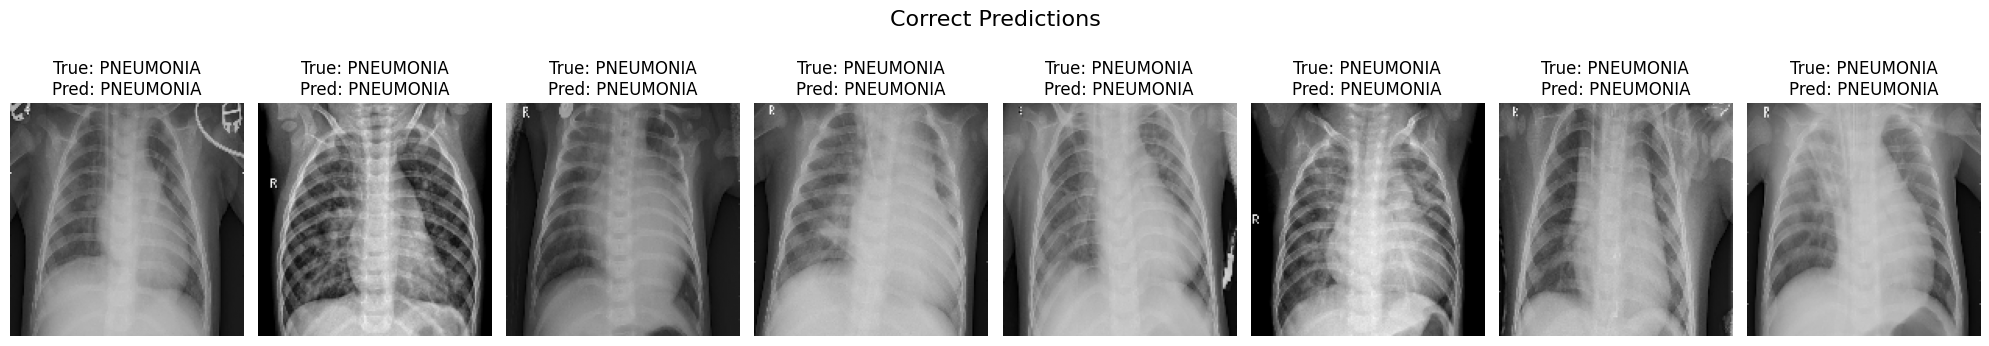

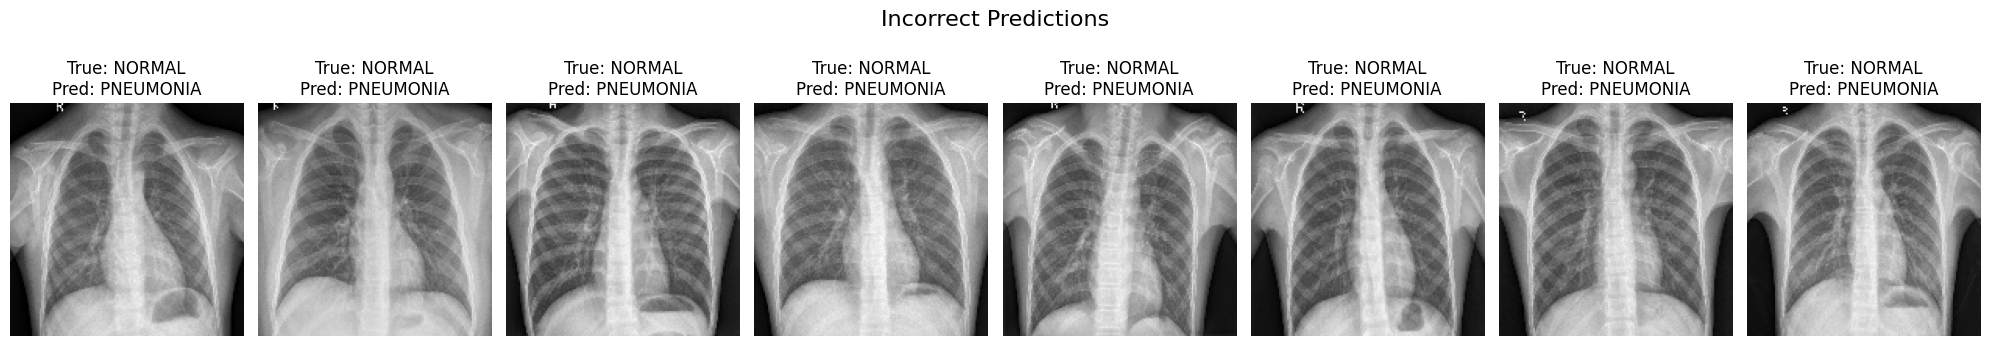

In [28]:
pred = model.predict(x_test)
pred_labels = np.argmax(pred, axis=1)
true_labels = y_test


correct = np.where(pred_labels == true_labels)[0]
incorrect = np.where(pred_labels != true_labels)[0]


def plot_images(indices, title, n=8):
    plt.figure(figsize=(20, 4))
    plt.suptitle(title, fontsize=16)
    for i, idx in enumerate(indices[:n]):
        plt.subplot(1, n, i+1)
        plt.imshow(x_test[idx].reshape(img_resize, img_resize), cmap='gray')
        plt.title(f"True: {labels[true_labels[idx]]}\nPred: {labels[pred_labels[idx]]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


plot_images(correct, "Correct Predictions")


plot_images(incorrect, "Incorrect Predictions")


In [30]:
model.save("model.h5")